In [215]:
from Functional_Fusion.dataset import DataSetMDTB
from Functional_Fusion.dataset import DataSetLanguage
import numpy as np
import pandas as pd
from Functional_Fusion import atlas_map as am
import nitools as nt
import SUITPy.flatmap as flatmap
import matplotlib.pyplot as plt
from itertools import combinations


In [216]:
base_dir = '/cifs/diedrichsen/data/FunctionalFusion'

# Define ROI

In [217]:
# ROI_labels = ['S1L', 'S2L', 'S3L', 'S4L', 'S5L', 'S1R', 'S2R', 'S3R', 'S4R', 'S5R']
# ROI_labels = ['S1R', 'S2R']

# ROI_labels = ['D1L', 'D2L', 'D3L', 'D4L', 'D1R', 'D2R', 'D3R', 'D4R']

ROI_labels = ['M1L', 'M2L', 'M3L', 'M4L', 'M1R', 'M2R', 'M3R', 'M4R']

<Axes: >

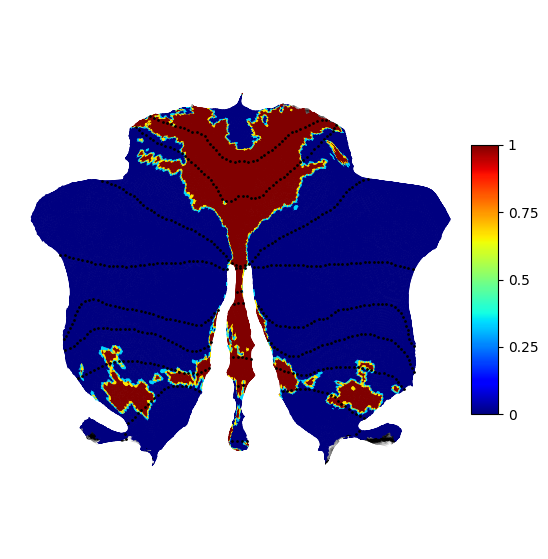

In [218]:
atlas, _ = am.get_atlas('SUIT3')
atlas_dir = f'{base_dir}/Atlases/tpl-SUIT'
model_name = f'/atl-NettekovenSym32_space-SUIT_dseg.nii'
U = atlas.read_data(atlas_dir + model_name)
U = U.T
_, cmap, labels = nt.read_lut(f'{atlas_dir}/atl-NettekovenSym32.lut')
ROI_mask = np.zeros_like(U)
for i, label in enumerate(labels):
    if label in ROI_labels:
        ROI_mask[U == i] = 1

lang_img = atlas.data_to_nifti(ROI_mask)
surface = flatmap.vol_to_surf(lang_img, space='SUIT',stats = 'mode')
flatmap.plot(data=surface, new_figure=True, colorbar=True, render='matplotlib')

# Load data

In [219]:
MDTB_dataset = DataSetMDTB(f'{base_dir}/MDTB')
data_mdtb,info_mdtb  =MDTB_dataset.get_data(space='SUIT3',ses_id='ses-s1',type='CondAll')
data_mdtb =np.nanmean(data_mdtb,axis =0)


/tmp/ipykernel_10687/1841978593.py:3: RuntimeWarning: Mean of empty slice
  data_mdtb =np.nanmean(data_mdtb,axis =0)


In [220]:
info_mdtb.cond_name

0                  NoGo
1                    Go
2                   ToM
3              VideoAct
4            VideoKnots
5      UnpleasantScenes
6        PleasantScenes
7                  Math
8        DigitJudgement
9          CheckerBoard
10             SadFaces
11           HappyFaces
12       IntervalTiming
13         MotorImagery
14         FingerSimple
15            FingerSeq
16          Verbal0Back
17          Verbal2Back
18          Object0Back
19          Object2Back
20    SpatialNavigation
21          StroopIncon
22            StroopCon
23              VerbGen
24             WordRead
25    VisualSearchSmall
26      VisualSearchMed
27    VisualSearchLarge
28                 rest
Name: cond_name, dtype: object

In [221]:
Language_dataset = DataSetLanguage(f'{base_dir}/Language')
data_language,info_language  =Language_dataset.get_data(space='SUIT3',ses_id='ses-localizer_cond',type='CondAll')
info_language['taskName'] = info_language['taskName'].str.strip()
data_language =np.nanmean(data_language,axis =0)
mean_across_conds = np.nanmean(data_language,axis =0)
data_language = data_language - mean_across_conds


/tmp/ipykernel_10687/1797386431.py:4: RuntimeWarning: Mean of empty slice
  data_language =np.nanmean(data_language,axis =0)
/tmp/ipykernel_10687/1797386431.py:5: RuntimeWarning: Mean of empty slice
  mean_across_conds = np.nanmean(data_language,axis =0)


In [222]:
data_language.shape

(18, 6918)

In [223]:
info_language.taskName

0                          rest
1                  word_reading
2               verb_GENERATION
3     action_observation_action
4            action_observation
5                intact_passage
6              degraded_passage
7               tongue_movement
8               finger_sequence
9                theory_of_mind
10           auditory_narrative
11                       n_back
12                      oddball
13                  demand_grid
14                romance_movie
15           spatial_navigation
16             sentence_reading
17              nonword_reading
Name: taskName, dtype: object

In [224]:
shared_conditions =[('theory_of_mind','ToM'),('rest','rest'),('finger_sequence','FingerSeq'),('action_observation_action','VideoAct'),('action_observation','VideoKnots'),('verb_GENERATION','VerbGen'),('word_reading','WordRead'),('spatial_navigation','SpatialNavigation')]

# Align each dataset to REST then average shared, stack all conds and align to mean of all tasks

In [225]:
# Subtract rest
rest_index = info_mdtb[info_mdtb['cond_name'] == 'rest'].index
data_mdtb_vrest = data_mdtb - data_mdtb[rest_index,:]

rest_index = info_language[info_language['taskName'] == 'rest'].index
data_language_vrest = data_language - data_language[rest_index,:]


In [226]:
# Average shared conds and add novel conds
shared_data = []
shared_labels = []

for lang_cond, mdtb_cond in shared_conditions:
    mdtb_index = info_mdtb[info_mdtb['cond_name'] == mdtb_cond].index
    lang_index = info_language[info_language['taskName'] == lang_cond].index
    
    if not mdtb_index.empty and not lang_index.empty:
        mdtb_cond_data = data_mdtb_vrest[mdtb_index, :].squeeze()
        lang_cond_data = data_language_vrest[lang_index, :].squeeze()
        
        # Average data across the shared conditions
        avg_data = (mdtb_cond_data + lang_cond_data) / 2
        shared_data.append(avg_data)
        shared_labels.append(mdtb_cond)  # use MDTB cond names for shared conditions

# Convert tp np array
shared_data = np.array(shared_data)

# Extract novel tasks from each dataset, excluding shared tasks
novel_data_mdtb = data_mdtb_vrest[~info_mdtb['cond_name'].isin([cond[1] for cond in shared_conditions]), :]
novel_data_language = data_language_vrest[~info_language['taskName'].isin([cond[0] for cond in shared_conditions]), :]

# Combine shared data with novel 
combined_data_v1 = np.vstack([shared_data, novel_data_mdtb, novel_data_language])

# Combine labels for shared and novel
combined_labels = shared_labels + \
                  info_mdtb[~info_mdtb['cond_name'].isin([cond[1] for cond in shared_conditions])]['cond_name'].tolist() + \
                  info_language[~info_language['taskName'].isin([cond[0] for cond in shared_conditions])]['taskName'].tolist()

# Create new info df
new_info_v1 = pd.DataFrame({
    'taskName': combined_labels,
    'source': ['shared']*len(shared_labels) + ['mdtb']*novel_data_mdtb.shape[0] + ['language']*novel_data_language.shape[0]
})

combined_data_v1.shape,new_info_v1


((39, 6918),
               taskName    source
 0                  ToM    shared
 1                 rest    shared
 2            FingerSeq    shared
 3             VideoAct    shared
 4           VideoKnots    shared
 5              VerbGen    shared
 6             WordRead    shared
 7    SpatialNavigation    shared
 8                 NoGo      mdtb
 9                   Go      mdtb
 10    UnpleasantScenes      mdtb
 11      PleasantScenes      mdtb
 12                Math      mdtb
 13      DigitJudgement      mdtb
 14        CheckerBoard      mdtb
 15            SadFaces      mdtb
 16          HappyFaces      mdtb
 17      IntervalTiming      mdtb
 18        MotorImagery      mdtb
 19        FingerSimple      mdtb
 20         Verbal0Back      mdtb
 21         Verbal2Back      mdtb
 22         Object0Back      mdtb
 23         Object2Back      mdtb
 24         StroopIncon      mdtb
 25           StroopCon      mdtb
 26   VisualSearchSmall      mdtb
 27     VisualSearchMed      mdtb
 

# Align each dataset to mean of shared then average shared, stack all conds and align to mean of all tasks

In [227]:
# Subtract mean of shared conditions (more stable?)
shared_indices = []
for cond_pair in shared_conditions:
    mdtb_index = info_mdtb[info_mdtb['cond_name'] == cond_pair[1]].index
    shared_indices.append(mdtb_index)
data_mdtb_vshared = data_mdtb - np.nanmean(data_mdtb[shared_indices,:].squeeze(),axis=0)
print(data_mdtb_vshared.shape)


shared_indices = []
for cond_pair in shared_conditions:
    language_index = info_language[info_language['taskName'] == cond_pair[0]].index
    shared_indices.append(language_index)
data_language_vshared = data_language - np.nanmean(data_language[shared_indices,:].squeeze(),axis=0)
print(data_language_vshared.shape)

(29, 6918)
(18, 6918)


/tmp/ipykernel_10687/4211961593.py:6: RuntimeWarning: Mean of empty slice
  data_mdtb_vshared = data_mdtb - np.nanmean(data_mdtb[shared_indices,:].squeeze(),axis=0)
/tmp/ipykernel_10687/4211961593.py:14: RuntimeWarning: Mean of empty slice
  data_language_vshared = data_language - np.nanmean(data_language[shared_indices,:].squeeze(),axis=0)


In [228]:
# Average shared conds and add novel conds
shared_data = []
shared_labels = []

for lang_cond, mdtb_cond in shared_conditions:
    mdtb_index = info_mdtb[info_mdtb['cond_name'] == mdtb_cond].index
    lang_index = info_language[info_language['taskName'] == lang_cond].index
    
    if not mdtb_index.empty and not lang_index.empty:
        mdtb_cond_data = data_mdtb_vshared[mdtb_index, :].squeeze()
        lang_cond_data = data_language_vshared[lang_index, :].squeeze()
        
        # average shared
        avg_data = (mdtb_cond_data + lang_cond_data) / 2
        shared_data.append(avg_data)
        shared_labels.append(mdtb_cond)  # use mdtb cond names for shared conds

# Convert to np
shared_data = np.array(shared_data)

# Extract novel tasks from each dataset, excluding shared tasks
novel_data_mdtb = data_mdtb_vshared[~info_mdtb['cond_name'].isin([cond[1] for cond in shared_conditions]), :]
novel_data_language = data_language_vshared[~info_language['taskName'].isin([cond[0] for cond in shared_conditions]), :]

# Combine shared data with novel data
combined_data_v2 = np.vstack([shared_data, novel_data_mdtb, novel_data_language])

# Combine labels for shared and novel data
combined_labels = shared_labels + \
                  info_mdtb[~info_mdtb['cond_name'].isin([cond[1] for cond in shared_conditions])]['cond_name'].tolist() + \
                  info_language[~info_language['taskName'].isin([cond[0] for cond in shared_conditions])]['taskName'].tolist()

# Create new info df
new_info_v2 = pd.DataFrame({
    'taskName': combined_labels,
    'source': ['shared']*len(shared_labels) + ['mdtb']*novel_data_mdtb.shape[0] + ['language']*novel_data_language.shape[0]
})

combined_data_v2.shape,new_info_v2


((39, 6918),
               taskName    source
 0                  ToM    shared
 1                 rest    shared
 2            FingerSeq    shared
 3             VideoAct    shared
 4           VideoKnots    shared
 5              VerbGen    shared
 6             WordRead    shared
 7    SpatialNavigation    shared
 8                 NoGo      mdtb
 9                   Go      mdtb
 10    UnpleasantScenes      mdtb
 11      PleasantScenes      mdtb
 12                Math      mdtb
 13      DigitJudgement      mdtb
 14        CheckerBoard      mdtb
 15            SadFaces      mdtb
 16          HappyFaces      mdtb
 17      IntervalTiming      mdtb
 18        MotorImagery      mdtb
 19        FingerSimple      mdtb
 20         Verbal0Back      mdtb
 21         Verbal2Back      mdtb
 22         Object0Back      mdtb
 23         Object2Back      mdtb
 24         StroopIncon      mdtb
 25           StroopCon      mdtb
 26   VisualSearchSmall      mdtb
 27     VisualSearchMed      mdtb
 

# MANUALLY find conditions of interest +rest, subtract the mean across conds from each voxel and check variance



In [229]:
combined_data_masked = combined_data_v1[:,ROI_mask == 1]

In [230]:
task1_index = new_info_v1[new_info_v1['taskName'] == 'sentence_reading'].index
task1_data = combined_data_masked[task1_index,:].squeeze()

task2_index = new_info_v1[new_info_v1['taskName'] == 'nonword_reading'].index
task2_data = combined_data_masked[task2_index,:].squeeze()

task_rest_index = new_info_v1[new_info_v1['taskName'] == 'VerbGen'].index
task_rest_data = combined_data_masked[task_rest_index,:].squeeze()
task_rest_data.shape

(1629,)

In [231]:
task_matrix = np.vstack((task1_data,task2_data,task_rest_data))
task_matrix = np.nan_to_num(task_matrix)

In [232]:
mean_across_conditions = task_matrix.mean(axis=0)
normalized_task_matrix = task_matrix - mean_across_conditions

In [233]:
nn =task_matrix @ task_matrix.T
eigenvalues_nn = np.linalg.eigvals(nn)
print(eigenvalues_nn)
print(np.sum(eigenvalues_nn))

[4.75170592 0.35897445 0.44572259]
5.5564029634124035


In [234]:
nn

array([[2.50696484, 2.02293145, 0.82436982],
       [2.02293145, 2.27402763, 0.80784595],
       [0.82436982, 0.80784595, 0.7754105 ]])

# Algorithm to search all combos

In [235]:
def find_best_task_combination(task_matrix, task_names, num_tasks=10, function='trace'):
    """Finds the combination of `num_tasks` that gives the highest eigenvalue sum."""
    best_output = -np.inf
    best_combination = None
    
    # Generate all task combos
    task_indices = list(range(len(task_names)))
    i=0
    for comb in combinations(task_indices, num_tasks):
        if i % 10000 == 0:
            print(i)
        subset_matrix = task_matrix[np.array(comb), :]
        subset_matrix = np.nan_to_num(subset_matrix)
        subset_matrix_mean = subset_matrix.mean(axis=0)
        subset_matrix = subset_matrix - subset_matrix_mean

        varcov = subset_matrix @ subset_matrix.T
        
        if function == 'trace':
            function_result = np.sum(np.linalg.eigvals(varcov))
        elif function =='DOD':
            diagonal_sum = np.trace(varcov)
            off_diagonal_sum = np.sum(varcov) - diagonal_sum
            function_result = diagonal_sum - off_diagonal_sum
        
        if function_result > best_output:
            best_output = function_result
            best_combination = comb
        i+=1
    
    # Return the best combinato + eigenvalue sum
    best_task_names = [task_names[i] for i in best_combination]
    return best_task_names, best_output

In [236]:
task_matrix = combined_data_v1[:,ROI_mask == 1]
task_names  =new_info_v1.taskName


In [237]:
best_tasks, highest_eigenvalue_sum = find_best_task_combination(task_matrix, task_names, num_tasks=5,function='DOD')
print("Best combination of tasks:", best_tasks)
print("Highest eigenvalue sum:", highest_eigenvalue_sum)

0
10000
20000
30000
40000
50000
60000
70000
80000
90000
100000
110000
120000
130000
140000
150000
160000
170000
180000
190000
200000
210000
220000
230000
240000
250000
260000
270000
280000
290000
300000
310000
320000
330000
340000
350000
360000
370000
380000
390000
400000
410000
420000
430000
440000
450000
460000
470000
480000
490000
500000
510000
520000
530000
540000
550000
560000
570000
Best combination of tasks: ['FingerSeq', 'NoGo', 'DigitJudgement', 'tongue_movement', 'romance_movie']
Highest eigenvalue sum: 53.15788518980378


In [238]:
best_tasks, highest_eigenvalue_sum = find_best_task_combination(task_matrix, task_names, num_tasks=5,function='trace')
print("Best combination of tasks:", best_tasks)
print("Highest eigenvalue sum:", highest_eigenvalue_sum)

0
10000
20000
30000
40000
50000
60000
70000
80000
90000
100000
110000
120000
130000
140000
150000
160000
170000
180000
190000
200000
210000
220000
230000
240000
250000
260000
270000
280000
290000
300000
310000
320000
330000
340000
350000
360000
370000
380000
390000
400000
410000
420000
430000
440000
450000
460000
470000
480000
490000
500000
510000
520000
530000
540000
550000
560000
570000
Best combination of tasks: ['FingerSeq', 'NoGo', 'DigitJudgement', 'tongue_movement', 'romance_movie']
Highest eigenvalue sum: 26.5789425949019
